In [1]:
# !pip install pennylane
# !pip install pennylane pennylane-lightning[gpu]

In [2]:
import pennylane as qml
from pennylane import numpy as np
from pennylane.templates import StronglyEntanglingLayers
import torch
import matplotlib.pyplot as plt
from torch.nn.functional import relu
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from skimage.transform import resize

/Users/aleksandrak/Desktop/thesis_experiments/.venv/lib/python3.12/site-packages/pennylane/__init__.py:212: PennyLaneDeprecationWarning: PennyLane v0.44 has dropped maintainence support for NumPy < 2.0.0. You have version 1.26.4 installed. Future versions of PennyLane will not work with NumPy<2.0. Please consider upgrading NumPy using `python -m pip install numpy --upgrade`. 
  warnings.warn(


### Dataset Preparation


First, we load the MNIST dataset from openML.
- X is the pixel data
- y is the labels
- converting everything to `uint8` here to ensure all values are integers in [0, 255]

In [3]:
# loading mnist from keras.datasets
from keras.datasets import mnist
(X_train_full, y_train_full), (X_test_full, y_test_full) = mnist.load_data()
X = np.concatenate((X_train_full, X_test_full), axis=0)
y = np.concatenate((y_train_full, y_test_full), axis=0)

X = X.astype(np.uint8) # better to convert for binerization
y = y.astype(np.uint8)
# digits = load_digits()

# X = digits.data        # shape (1797, 64)
# y = digits.target      # labels 0–9


2026-03-16 23:55:57.375421: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [4]:
X.shape

(70000, 28, 28)

Next, we focus on 2 classes, i.e. binary classification.
Here, I've been experimenting with different classes, and I stopped on 4 vs 9, cause they have more subtle difference in pixels, they are similar looking.

In [5]:
# focus on binary classification
mask = (y == 4) | (y == 9)

X, y = X[mask], y[mask]
X.shape

(13782, 28, 28)

In [6]:
n_samples = 300

X = X.values if hasattr(X, "values") else X # safer conversion

X = X[:n_samples]
y = y[:n_samples]

In [7]:
print("Unique labels:", np.unique(y))

Unique labels: [4 9]


In [8]:
y = np.where(y == 4, -1, 1)
print("Unique labels:", np.unique(y))

Unique labels: [-1  1]


- I take only the first `n_samples`.
- I convert X to a NumPy array, and shuffling the data randomly

Now, I normalise pixel intensities.
- [0, 255] -> [0, 1]
- reshaping images back to 2D for resizing, i.e to 28x28 array with float values between 0 and 1.

In [9]:
X = X / 255.0
X = X.reshape(-1, 28, 28)

print(X.shape)
print("Pixel range:", X.min(), X.max())

(300, 28, 28)
Pixel range: 0.0 1.0


And now I reduce images to 8x8 + flattening to (, 64)
- resize -> flatten -> normalize

In [10]:
# convert each 28x28 binarised image to 8x8, then flatten to length 64
def to_8x8_vector(img_row):
    img_8x8 = resize(
        img_row,
        (8, 8),
        anti_aliasing=True,
        preserve_range=True,
        order=1 # controlling interpolation
    )
    img_8x8 = img_8x8.flatten().astype(float)
    # img_8x8 -= img_8x8.mean()
    norm = np.linalg.norm(img_8x8)
    if norm > 0:
        img_8x8 /= norm
    else:
        img_8x8[0] = 1.0
      # should be shape (64,)
    return img_8x8

# apply transformation to all images
X_8x8 = np.array([to_8x8_vector(x) for x in X], dtype=float)
X_8x8.shape

(300, 64)

In [11]:
# sanity check, make sure no NaNs exist and all vectors are normalised, i.e. norm is around 1
print("Any NaNs?", np.isnan(X_8x8).any())
print("Norm check:", np.min(np.linalg.norm(X_8x8, axis=1)), np.max(np.linalg.norm(X_8x8, axis=1)))

Any NaNs? False
Norm check: 0.9999999999999998 1.0000000000000002


I'm gonna do the splitting here, and carry both representations consistently.
- qek inputs: (64,) flattened and normalized vectors, for quantum kernel embedding
- qjpeg: 28x28 images

In [12]:
idx = np.arange(n_samples)

idx_train, idx_test, y_train, y_test = train_test_split(
    idx, y, test_size=0.2, random_state=42, stratify=y, shuffle=True
)

# QEK inputs (8x8 -> 64 -> normed)
X_train_qek = X_8x8[idx_train]
X_test_qek  = X_8x8[idx_test]

print("QEK train/test:", X_train_qek.shape, X_test_qek.shape)
print("Labels train/test:", y_train.shape, y_test.shape)

QEK train/test: (240, 64) (60, 64)
Labels train/test: (240,) (60,)


Data preparation is done.

### Device

In [13]:
n_qubits = 6
dev_ideal = qml.device('default.qubit', wires=n_qubits)

### Defining Functions

In [14]:
import torch
import pennylane as qml
import numpy as np
from torch.nn.functional import relu

# -----------------------------
# Quantum circuit components
# -----------------------------
def qek_layer_amplitude(x, theta):
    # Data re-uploading via phase gates (breaks kernel symmetry)
    wires = range(n_qubits)
    for l in range(theta.shape[0]):
        qml.AmplitudeEmbedding(
        x,
        wires=range(n_qubits),
        normalize=False
    )
        i = 0
        for j, wire in enumerate(wires):
            qml.Hadamard(wires=[wire])
            qml.RZ(x[i % len(x)], wires=[wire])
            i += 1
            qml.RY(theta[l, j, 0], wires=wire)

        # Trainable block
        for q in range(n_qubits):
            qml.CRZ(theta[l, q, 0], wires=[q % n_qubits, (q + 1) % n_qubits])

def qek_embedding_amplitude(x, theta):
    qek_layer_amplitude(x, theta)

# -----------------------------
# Quantum kernel QNode
# -----------------------------
@qml.qnode(dev_ideal, interface="torch", diff_method="backprop")
def qek_kernel_base(x1, x2, theta, n_qubits):
    """Adjoint-based kernel: |<phi(x1)|phi(x2)>|^2."""
    qek_embedding_amplitude(x1, theta)
    qml.adjoint(qek_embedding_amplitude)(x2, theta)
    return qml.expval(qml.Projector([0]*n_qubits, wires=range(n_qubits)))

def split_indices(N, block_size):
    """Return a list of index blocks for M-SPLIT."""
    blocks = []
    for start in range(0, N, block_size):
        end = min(start + block_size, N)
        blocks.append(np.arange(start, end))
    return blocks

def compute_block_kernel(X, theta, block_idx, n_qubits):
    """Compute PSD-corrected kernel block."""
    X_block = X[block_idx]
    n = len(block_idx)
    K_block = torch.zeros((n, n), dtype=X_block.dtype, device=X_block.device)

    for i in range(n):
        for j in range(i, n):
            val = qek_kernel_base(X_block[i], X_block[j], theta, n_qubits)
            K_block[i, j] = val.to(torch.float32)
            K_block[j, i] = val.to(torch.float32)

    # PSD projection
    K_block_np = K_block.detach().numpy()
    eigvals, eigvecs = np.linalg.eigh(K_block_np)
    eigvals[eigvals < 0] = 0
    K_block_psd = torch.tensor(eigvecs @ np.diag(eigvals) @ eigvecs.T, dtype=X_block.dtype)

    # Normalize diagonals to 1
    diag = torch.sqrt(torch.diag(K_block_psd))
    K_block_psd /= diag[:, None]
    K_block_psd /= diag[None, :]

    return K_block_psd

def kernel_matrix(X, theta):

    n = len(X)

    K = torch.zeros((n, n), dtype=torch.float32)

    for i in range(n):
        for j in range(i, n):

            val = qek_kernel_base(X[i], X[j], theta, 6)

            K[i, j] = val
            K[j, i] = val

    return K


def msplit_kernel(X, theta, n_qubits, block_size=10):
    N = len(X)
    blocks = split_indices(N, block_size)
    K = torch.zeros((N, N), dtype=torch.float32)

    # Compute each block independently
    for block in blocks:
        K_block = compute_block_kernel(X, theta, block, n_qubits)
        idx = np.ix_(block, block)
        K[idx] = K_block

    return K

# -----------------------------
# Minibatch kernel matrix
# -----------------------------
def kernel_matrix_minibatch(X_batch, theta, n_qubits):
    """Compute symmetric kernel matrix for a minibatch."""
    n = X_batch.shape[0]
    K = torch.zeros((n, n), dtype=X_batch.dtype)
    for i in range(n):
        for j in range(i, n):
            val = qek_kernel_base(X_batch[i], X_batch[j], theta, n_qubits)
            K[i, j] = val
            K[j, i] = val
    return K

# -----------------------------
# Hinge loss for SVM
# -----------------------------
def hinge_loss_kernel(K, y, alpha):
    """Squared hinge loss with dual variables alpha."""
    preds = K @ (alpha * y)
    return torch.mean(relu(1 - y * preds) ** 2)

def kernel_target_alignment(K, y):
    """
    Computes differentiable kernel-target alignment for batch.
    K: (N,N) kernel matrix (torch.Tensor)
    y: (N,) labels in {-1,1} (torch.Tensor)
    """
    y = y.view(-1,1)  # ensure column vector
    K_star = y @ y.T  # ideal kernel matrix
    num = torch.sum(K * K_star)
    den = torch.sqrt(torch.sum(K**2) * torch.sum(K_star**2))
    return num / den


def compute_block_kernel_train(X, theta, block_idx, n_qubits):
    """Differentiable kernel block (no PSD projection)."""

    X_block = X[block_idx]
    n = len(block_idx)

    # Collect values to avoid in-place operations
    kernel_values_rows = []
    for i in range(n):
        row_values = []
        for j in range(n):
            if j < i:
                # Leverage symmetry to avoid recomputing
                row_values.append(kernel_values_rows[j][i])
            else:
                val = qek_kernel_base(X_block[i], X_block[j], theta, n_qubits)
                row_values.append(val.to(torch.float32))
        kernel_values_rows.append(row_values)

    # Stack the collected tensor values to form K_block
    K_block = torch.stack([torch.stack(row) for row in kernel_values_rows])

    return K_block

def msplit_kernel_train(X, theta, n_qubits, block_size=10):
    N = len(X)
    blocks = split_indices(N, block_size)
    K = torch.zeros((N, N), dtype=torch.float32) # K here does not need requires_grad=True if filled by gradient-tracking tensors

    # Compute each block independently
    for block in blocks:
        K_block = compute_block_kernel_train(X, theta, block, n_qubits) # Call the differentiable version
        idx = np.ix_(block, block)
        K[idx] = K_block

    return K


def quantum_kernel_train_kta(X_train, y_train, n_qubits,
                             n_layers=2, steps=150, batch_size=12,
                             lr=1e-3, block_size=6, verbose=True):

    N = len(X_train)

    X_train = torch.as_tensor(X_train, dtype=torch.float32)
    y_train = torch.as_tensor(y_train, dtype=torch.float32)


    theta = torch.tensor(
        np.random.normal(0, 0.1, (n_layers, n_qubits, 1)),
        dtype=torch.float32,
        requires_grad=True
    )

    optimizer = torch.optim.Adam([theta], lr=lr)

    kta_history = []

    for step in range(steps):

        optimizer.zero_grad()

        idx = np.random.choice(N, batch_size, replace=False)

        Xb = X_train[idx]
        yb = y_train[idx]

        Kb = msplit_kernel_train(Xb, theta, n_qubits, block_size)

        alignment = kernel_target_alignment(Kb, yb)

        loss = -alignment
        loss.backward()

        optimizer.step()

        kta_history.append(alignment.item())

        if verbose and step % 5 == 0:
            print(f"Step {step:03d} | KTA = {alignment.item():.4f}")

    return theta, kta_history


### Training theta

In [15]:
theta_1, loss_history_1 = quantum_kernel_train_kta(
    X_train_qek,
    y_train,
    n_qubits=n_qubits,
    n_layers=1,
    steps=150,
    batch_size=12
)


Step 000 | KTA = 0.2484
Step 005 | KTA = 0.2067
Step 010 | KTA = 0.1642
Step 015 | KTA = 0.3023
Step 020 | KTA = 0.3627
Step 025 | KTA = 0.1345
Step 030 | KTA = 0.1446
Step 035 | KTA = 0.1143
Step 040 | KTA = 0.1888
Step 045 | KTA = 0.3600
Step 050 | KTA = 0.2521
Step 055 | KTA = 0.2216
Step 060 | KTA = 0.4861
Step 065 | KTA = 0.1654
Step 070 | KTA = 0.1845
Step 075 | KTA = 0.1492
Step 080 | KTA = 0.1489
Step 085 | KTA = 0.1615
Step 090 | KTA = 0.1580
Step 095 | KTA = 0.1156
Step 100 | KTA = 0.1515
Step 105 | KTA = 0.1889
Step 110 | KTA = 0.1676
Step 115 | KTA = 0.1691
Step 120 | KTA = 0.2373
Step 125 | KTA = 0.1660
Step 130 | KTA = 0.1996
Step 135 | KTA = 0.1551
Step 140 | KTA = 0.2262
Step 145 | KTA = 0.2476


In [16]:
theta_rand = torch.randn_like(theta_1)

K_test = kernel_matrix(X_train_qek[:20], theta_rand)
print(K_test.mean())

/Users/aleksandrak/Desktop/thesis_experiments/.venv/lib/python3.12/site-packages/pennylane/math/interface_utils.py:137: UserWarning: Contains tensors of types {'torch', 'autograd'}; dispatch will prioritize TensorFlow, PyTorch, and Jax over Autograd. Consider replacing Autograd with vanilla NumPy.
  warnings.warn(


tensor(0.6092)


In [17]:
theta_2, loss_history_2 = quantum_kernel_train_kta(
    X_train_qek,
    y_train,
    n_qubits=n_qubits,
    n_layers=2,
    steps=150,
    batch_size=12
)


Step 000 | KTA = 0.3008
Step 005 | KTA = 0.2471
Step 010 | KTA = 0.0890
Step 015 | KTA = 0.1295
Step 020 | KTA = 0.1784
Step 025 | KTA = 0.1081
Step 030 | KTA = 0.4858
Step 035 | KTA = 0.3191
Step 040 | KTA = 0.2230
Step 045 | KTA = 0.2638
Step 050 | KTA = 0.1489
Step 055 | KTA = 0.0800
Step 060 | KTA = 0.4540
Step 065 | KTA = 0.1013
Step 070 | KTA = 0.2957
Step 075 | KTA = 0.1037
Step 080 | KTA = 0.2075
Step 085 | KTA = 0.2236
Step 090 | KTA = 0.2527
Step 095 | KTA = 0.2303
Step 100 | KTA = 0.2856
Step 105 | KTA = 0.1570
Step 110 | KTA = 0.1848
Step 115 | KTA = 0.2678
Step 120 | KTA = 0.1879
Step 125 | KTA = 0.1236
Step 130 | KTA = 0.2724
Step 135 | KTA = 0.1500
Step 140 | KTA = 0.2150
Step 145 | KTA = 0.2341


In [18]:
theta_4, loss_history_4 = quantum_kernel_train_kta(
    X_train_qek,
    y_train,
    n_qubits=n_qubits,
    n_layers=4,
    steps=150,
    batch_size=12
)

Step 000 | KTA = 0.5442
Step 005 | KTA = 0.2460
Step 010 | KTA = 0.3063
Step 015 | KTA = 0.1152
Step 020 | KTA = 0.2077
Step 025 | KTA = 0.1473
Step 030 | KTA = 0.2677
Step 035 | KTA = 0.1542
Step 040 | KTA = 0.1256
Step 045 | KTA = 0.4044
Step 050 | KTA = 0.1069
Step 055 | KTA = 0.1387
Step 060 | KTA = 0.2693
Step 065 | KTA = 0.1291
Step 070 | KTA = 0.2068
Step 075 | KTA = 0.1248
Step 080 | KTA = 0.2075
Step 085 | KTA = 0.2093
Step 090 | KTA = 0.1812
Step 095 | KTA = 0.0999
Step 100 | KTA = 0.2563
Step 105 | KTA = 0.1102
Step 110 | KTA = 0.1230
Step 115 | KTA = 0.2301
Step 120 | KTA = 0.2968
Step 125 | KTA = 0.2623
Step 130 | KTA = 0.1778
Step 135 | KTA = 0.3061
Step 140 | KTA = 0.3022
Step 145 | KTA = 0.3049


### Visuals

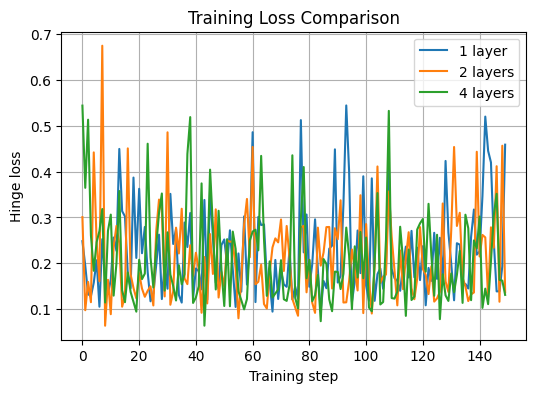

In [39]:
plt.figure(figsize=(6,4))

plt.plot(loss_history_1, label="1 layer")
plt.plot(loss_history_2, label="2 layers")
plt.plot(loss_history_4, label="4 layers")
# plt.plot(history_5, label="5 layers")
# plt.plot(history_6, label="6 layers")

plt.xlabel("Training step")
plt.ylabel("Hinge loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.grid(True)

plt.show()

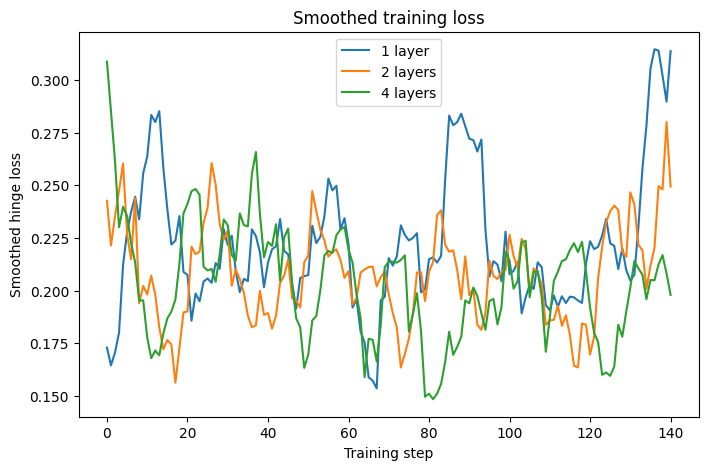

In [20]:
def smooth(x, w=10):
    return np.convolve(x, np.ones(w) / w, mode="valid")

plt.figure(figsize=(8,5))
plt.plot(smooth(loss_history_1), label="1 layer")
plt.plot(smooth(loss_history_2), label="2 layers")
plt.plot(smooth(loss_history_4), label="4 layers")
# plt.plot(smooth(history_5), label="5 layers")
# plt.plot(smooth(history_6), label="6 layers")

plt.xlabel("Training step")
plt.ylabel("Smoothed hinge loss")
plt.title("Smoothed training loss")
plt.legend()
plt.grif=True

plt.show()

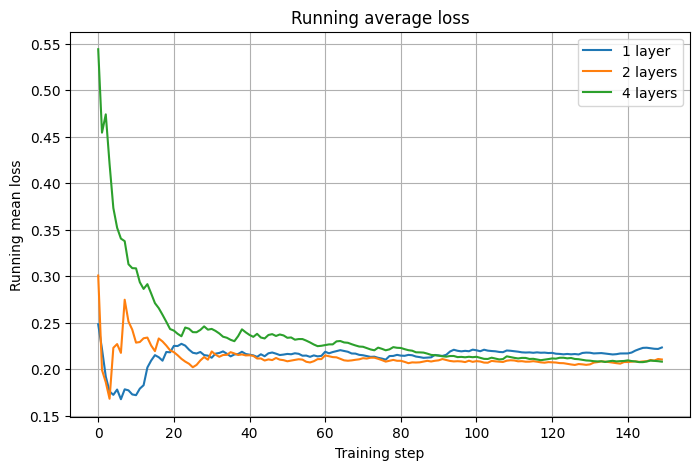

In [32]:
def running_mean(x):
    return np.cumsum(x) / np.arange(1, len(x) + 1)

plt.figure(figsize=(8,5))

plt.plot(running_mean(loss_history_1), label="1 layer")
plt.plot(running_mean(loss_history_2), label="2 layers")
plt.plot(running_mean(loss_history_4), label="4 layers")
# plt.plot(running_mean(history_5), label="5 layers")
# plt.plot(running_mean(history_6), label="6 layers")

plt.xlabel("Training step")
plt.ylabel("Running mean loss")
plt.title("Running average loss")

plt.legend()
plt.grid(True)

plt.show()

### Kernel Calculation

In [22]:
theta_random = torch.randn_like(theta_1)

In [44]:
X_train_qek_torch = torch.as_tensor(X_train_qek, dtype=torch.float32)
K_train = msplit_kernel(X_train_qek_torch, theta_1, n_qubits, block_size=12)

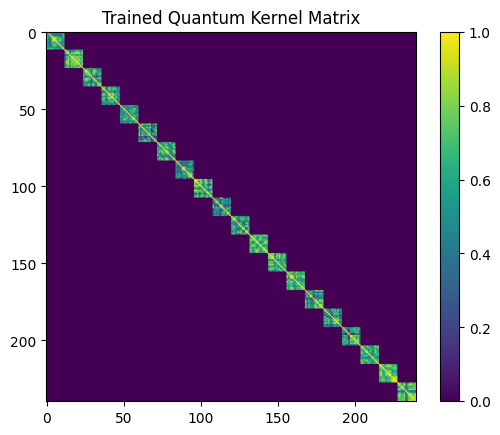

In [45]:
import matplotlib.pyplot as plt

plt.imshow(K_train.detach().numpy(), cmap="viridis")
plt.colorbar()
plt.title("Trained Quantum Kernel Matrix")
plt.show()


In [46]:
import numpy as np

K = K_train.detach().numpy()

off_diag = K[~np.eye(K.shape[0],dtype=bool)]

print("off-diagonal mean:", off_diag.mean())
print("off-diagonal max:", off_diag.max())
print("off-diagonal min:", off_diag.min())


off-diagonal mean: 0.026733236
off-diagonal max: 0.9526262
off-diagonal min: 0.0


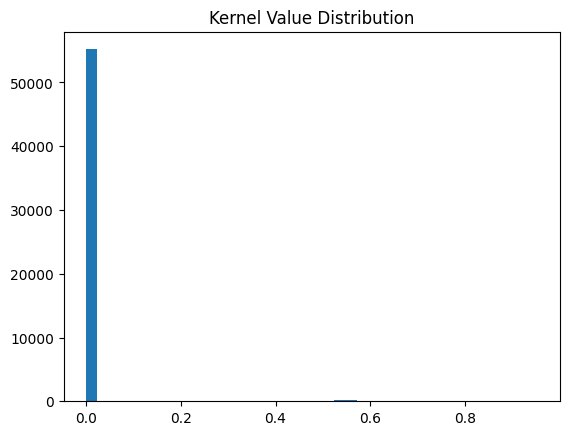

In [37]:
import matplotlib.pyplot as plt

plt.hist(off_diag, bins=40)
plt.title("Kernel Value Distribution")
plt.show()


### Predict

In [47]:
from sklearn.svm import SVC


K_train_np = K_train.detach().numpy()

clf = SVC(kernel='precomputed')
clf.fit(K_train_np, y_train)

# Compute test kernel
K_test_np = np.array([[qek_kernel_base(x1, x2, theta_random, n_qubits).item()
                       for x2 in X_train_qek] for x1 in X_test_qek])

y_pred = clf.predict(K_test_np)

from sklearn.metrics import accuracy_score
print("Test accuracy:", accuracy_score(y_test, y_pred))

/Users/aleksandrak/Desktop/thesis_experiments/.venv/lib/python3.12/site-packages/pennylane/math/interface_utils.py:137: UserWarning: Contains tensors of types {'torch', 'autograd'}; dispatch will prioritize TensorFlow, PyTorch, and Jax over Autograd. Consider replacing Autograd with vanilla NumPy.
  warnings.warn(


KeyboardInterrupt: 

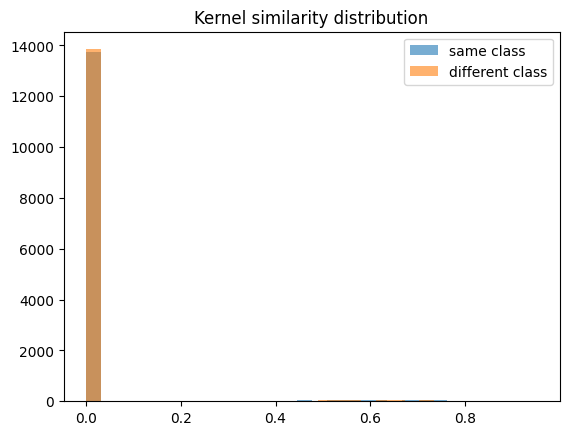

In [28]:
same = []
diff = []

for i in range(len(X_train_qek)):
    for j in range(i+1, len(X_train_qek)):
        k = K_train_np[i,j]
        if y_train[i] == y_train[j]:
            same.append(k)
        else:
            diff.append(k)

import matplotlib.pyplot as plt

plt.hist(same, bins=30, alpha=0.6, label="same class")
plt.hist(diff, bins=30, alpha=0.6, label="different class")
plt.legend()
plt.title("Kernel similarity distribution")
plt.show()


In [49]:
K_1 = msplit_kernel(X_train_qek_torch, theta_1, n_qubits)
K_4 = msplit_kernel(X_train_qek_torch, theta_4, n_qubits)

diff = torch.norm(K_1 - K_4)
print(diff)

tensor(0.0069)


Layers do have effect, it's just very very small

In [29]:
def kernel_target_alignment(K, y):
    K_np = K.detach().numpy()
    K_star = np.outer(y, y)
    num = np.sum(K_np * K_star)
    den = np.sqrt(np.sum(K_np**2) * np.sum(K_star**2))
    return num / den

kta = kernel_target_alignment(K_train, y_train)
print("Kernel-Target Alignment:", kta)


Kernel-Target Alignment: 0.04214646589375625


In [30]:
y_train_shuffled = np.random.permutation(y_train)
clf_test = SVC(kernel='precomputed')
clf_test.fit(K_train_np, y_train_shuffled)

y_pred = clf_test.predict(K_test_np)

accuracy_score(y_test, y_pred)

0.6

In [31]:
train_set = set(map(tuple, X_train_qek))
test_set = set(map(tuple, X_test_qek))

len(train_set.intersection(test_set))

0